# Variational Inference

> Tutorial: https://towardsdatascience.com/variational-inference-the-basics-f70ac511bcea/
>
> Code:https://colab.research.google.com/drive/1NPZfRkhrFfX8flbUJqfgKZ2z1w5JXs1R?usp=sharing#scrollTo=b7NneR557ONX

In [43]:
from functools import partial

import jax
from jax import jit, grad, random, vmap
import jax.numpy as jnp
import jax.scipy as jsp
from matplotlib import pyplot as plt
import optax
from sklearn import datasets

In [44]:
digits = datasets.load_digits()
is_zero = digits.target == 0
X_train = digits.images[is_zero]

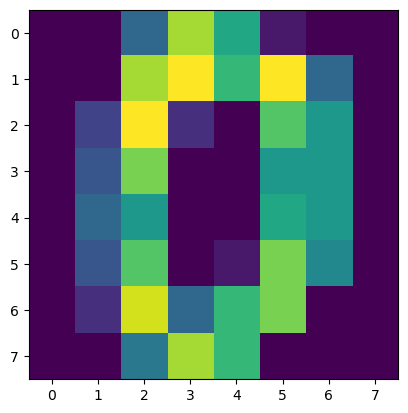

In [45]:
plt.imshow(X_train[0])
plt.show()

In [46]:
n_pixels = 64
X_train = X_train.reshape((-1, n_pixels))

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

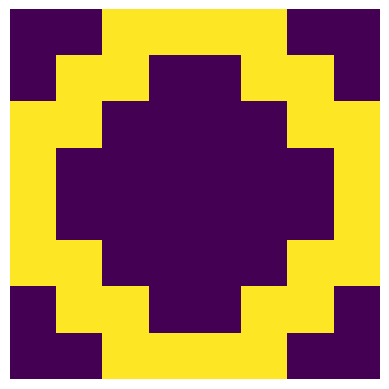

In [47]:
x_domain_knowledge = jnp.array(
  [[ 1,  1, 16, 16, 16, 16,  1,  1],
  [ 1, 16, 16,  1,  1, 16, 16,  1],
  [16, 16,  1,  1,  1,  1, 16, 16],
  [16,  1,  1,  1,  1,  1,  1, 16],
  [16,  1,  1,  1,  1,  1,  1, 16],
  [16, 16,  1,  1,  1,  1, 16, 16],
  [ 1, 16, 16,  1,  1, 16, 16,  1],
  [ 1,  1, 16, 16, 16, 16,  1,  1]],
).flatten()
plt.imshow(x_domain_knowledge.reshape(8, 8))
plt.axis('off')

In [48]:
# Hyperparameters of the model.
a = 2. * x_domain_knowledge
b = 2.

def log_joint(θ):
  log_likelihood = jnp.sum(jsp.stats.gamma.logpdf(θ, a, scale=1./b))
  log_likelihood += jnp.sum(jsp.stats.poisson.logpmf(X_train, θ))
  return log_likelihood

In [49]:
# from pandas.io.formats.printing import Dict
@partial(vmap, in_axes=(0, None, None))
def evidence_lower_bound(θ_i, alpha, inv_beta):
  elbo = log_joint(θ_i) - jnp.sum(jsp.stats.gamma.logpdf(θ_i, alpha, scale=inv_beta))
  return elbo

def loss(Φ: dict, key):
  """Stochastic estimate of evidence lower bound."""
  alpha = jnp.exp(Φ['log_alpha'])
  inv_beta = jnp.exp(-Φ['log_beta'])

  # Sample a batch from variational distribution q.
  batch_size = 128
  θ_samples = random.gamma(key, alpha , shape=[batch_size, n_pixels]) * inv_beta

  # Compute Monte Carlo estimate of evidence lower bound.
  elbo_loss = jnp.mean(evidence_lower_bound(θ_samples, alpha, inv_beta))

  # Turn elbo into a loss.
  return -elbo_loss

In [50]:
# Initialise parameters using prior.
Φ = {
    'log_alpha': jnp.log(a),
    'log_beta': jnp.full(fill_value=jnp.log(b), shape=[n_pixels]),
}

loss_val_grad = jit(jax.value_and_grad(loss))
optimiser = optax.adam(learning_rate=0.2)
opt_state = optimiser.init(Φ)

In [51]:
n_iter = 5_000
key, rng_key = random.split(random.PRNGKey(42))
keys = random.split(rng_key, num=n_iter)

for i, key in enumerate(keys):
  elbo, grads = loss_val_grad(Φ, key)
  updates, opt_state = optimiser.update(grads, opt_state)
  Φ = optax.apply_updates(Φ, updates)
  if i % 100 == 0:
    print(f'{i}: ELBO loss', elbo)

0: ELBO loss 114792.625
100: ELBO loss 22565.418
200: ELBO loss 22038.725
300: ELBO loss 21849.152
400: ELBO loss 21742.537
500: ELBO loss 21688.33
600: ELBO loss 21654.787
700: ELBO loss 21630.883
800: ELBO loss 21617.22
900: ELBO loss 21605.24
1000: ELBO loss 21599.926
1100: ELBO loss 21591.342
1200: ELBO loss 21588.719
1300: ELBO loss 21581.766
1400: ELBO loss 21581.605
1500: ELBO loss 21578.402
1600: ELBO loss 21574.988
1700: ELBO loss 21576.059
1800: ELBO loss 21573.543
1900: ELBO loss 21573.945
2000: ELBO loss 21572.328
2100: ELBO loss 21570.467
2200: ELBO loss 21573.16
2300: ELBO loss 21571.113
2400: ELBO loss 21569.297
2500: ELBO loss 21571.797
2600: ELBO loss 21569.922
2700: ELBO loss 21569.602
2800: ELBO loss 21570.389
2900: ELBO loss 21570.71
3000: ELBO loss 21569.158
3100: ELBO loss 21570.857
3200: ELBO loss 21571.117
3300: ELBO loss 21571.652
3400: ELBO loss 21572.781
3500: ELBO loss 21569.219
3600: ELBO loss 21573.055
3700: ELBO loss 21571.025
3800: ELBO loss 21570.543
39

In [52]:
alpha = jnp.exp(Φ['log_alpha'])
inv_beta = jnp.exp(-Φ['log_beta'])
θ_interval = jnp.linspace(0, 16, 100)[:, None]

# Variational density.
q_z = jsp.stats.gamma.pdf(θ_interval, alpha, scale=inv_beta)

# Density of exact solution.
alpha_true = a + X_train.sum(axis=0)
beta_true = b + len(X_train)
p_z_true = jsp.stats.gamma.pdf(θ_interval, alpha_true, scale=1/(beta_true))

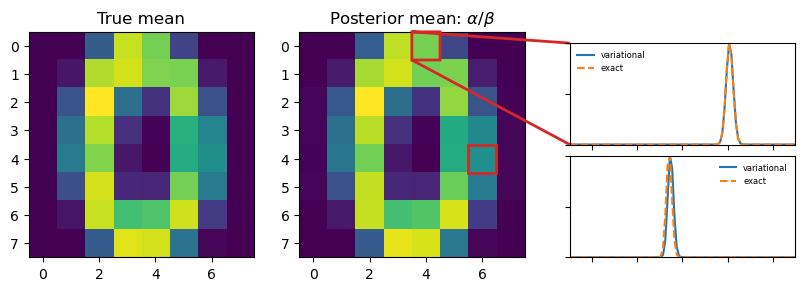

In [60]:
f, axs = plt.subplots(1, 2)
axs[0].set_title('True mean')
axs[0].imshow(X_train.mean(axis=0).reshape(8, 8))
axs[1].set_title(r'Posterior mean: $\alpha / \beta$')
mean = alpha * inv_beta
axs[1].imshow(mean.reshape(8, 8))

def inset_distribution(x, y, alpha, inv_beta, ax):
  """Inset comparing exact with variational solution"""
  ax.set_xlim(x-0.5, x+0.5)
  ax.set_ylim(y-0.5, y+0.5)
  ax.set_xticklabels([])
  ax.set_yticklabels([])

  p_var = q_z.reshape(-1, 8, 8)[:, y, x]
  p_true = p_z_true.reshape(-1, 8, 8)[:, y, x]
  prob_scale = max(*p_var, *p_true)
  # Shift to (x, y) and scale to (1, 1).
  x_transl = θ_interval/16 + x - 0.5
  y_var = p_var / prob_scale + y - 0.5
  y_true = p_true / prob_scale + y - 0.5
  ax.plot(x_transl, y_var, '-', label='variational')
  ax.plot(x_transl, y_true, '--', label='exact')
  ax.legend(frameon=False, prop={'size': 6}, loc='best')


axin1 = axs[1].inset_axes([1.2, 0.5, 1.0, 0.45])
axin2 = axs[1].inset_axes([1.2, 0.0, 1.0, 0.45])

inset_distribution(4, 0, alpha, inv_beta, axin1)
axs[1].indicate_inset_zoom(axin1, edgecolor="tab:red", linewidth=2.0, alpha=1.)

inset_distribution(6, 4, alpha, inv_beta, axin2)
axs[1].indicate_inset_zoom(axin2, edgecolor="tab:red", linewidth=2.0, alpha=1.)

In [53]:
# 1) Generate pixel-level intensities for 10 images.
key_θ, key_x = random.split(key)
m_new_images, n_pixels = 10, 64
θ_samples = random.gamma(key_θ, alpha , shape=[m_new_images, n_pixels]) * inv_beta

# 2) Sample 10 image from intensities.
X_synthetic = random.poisson(key_x, θ_samples)

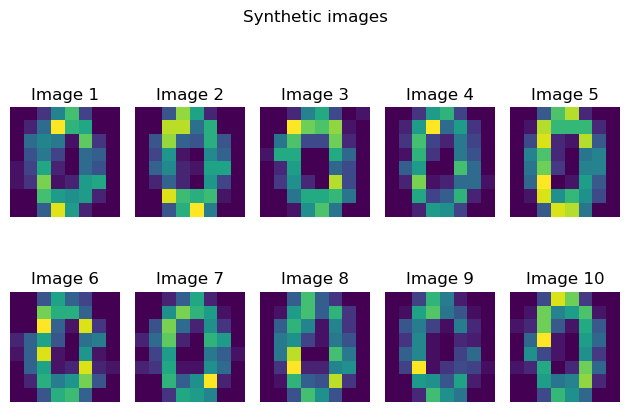

In [54]:
f, axs = plt.subplots(2, 5)
f.suptitle('Synthetic images')
for i, (x_i, ax) in enumerate(zip(X_synthetic, axs.flatten())):
  ax.set_title(f'Image {i+1}')
  ax.imshow(x_i.reshape(8, 8))
  ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()

In [59]:
jnp.exp(Φ['log_alpha'])

Array([1.9438173e+00, 6.3028054e+00, 7.7473065e+02, 2.3449778e+03,
       2.0348123e+03, 5.5047839e+02, 8.2288904e+00, 1.9418873e+00,
       1.8959297e+00, 1.8881694e+02, 2.2632410e+03, 2.3236833e+03,
       2.0048173e+03, 2.0684551e+03, 2.0365430e+02, 2.0753183e+00,
       3.1952673e+01, 6.9521753e+02, 2.4624834e+03, 9.2747437e+02,
       3.7616376e+02, 2.1290134e+03, 6.5571100e+02, 3.1746145e+01,
       3.1979103e+01, 9.4483820e+02, 2.2349192e+03, 3.5561304e+02,
       2.5953047e+01, 1.5827771e+03, 1.1675542e+03, 3.1935879e+01,
       3.1740362e+01, 1.0280460e+03, 2.0118800e+03, 1.6512988e+02,
       9.9758511e+00, 1.5708896e+03, 1.2904417e+03, 3.2331001e+01,
       3.2224010e+01, 6.4895306e+02, 2.2676926e+03, 2.9659683e+02,
       2.7407230e+02, 1.9857925e+03, 1.0779473e+03, 3.1805117e+01,
       1.9739397e+00, 1.7518808e+02, 2.3319517e+03, 1.7610773e+03,
       1.8559822e+03, 2.3887349e+03, 4.6066949e+02, 2.0818107e+00,
       2.0623932e+00, 2.8625975e+00, 7.5812549e+02, 2.4569016e